# Getting Started with `snbb_atlas_pack`

This notebook demonstrates the core Python API for the **SNBB Atlas Pack** — a BIDS-compatible collection of 46 brain parcellation atlases covering subcortical, cortical, and combined spaces.

**Atlases included:**

| Family | Count | Space | Format |
|--------|------:|-------|--------|
| Tian Melbourne Subcortex (S1–S4) | 4 | MNI152NLin2009cAsym 1 mm | NIfTI |
| HCPex (cortex + subcortex) | 1 | MNI152NLin2009cAsym 1 mm | NIfTI |
| HCP-MMP 1.0 (surface) | 1 | fsLR 32k | GIFTI |
| Schaefer2018 + Tian (combined) | 40 | MNI152NLin2009cAsym 1 mm | NIfTI |

> **Prerequisites:** `uv sync` from the repo root to install dependencies.

In [1]:
import snbb_atlas_pack as snbb
import pandas as pd
import nibabel as nib
import numpy as np

print(f"snbb_atlas_pack loaded — {len(snbb.list_atlases())} atlases available")

snbb_atlas_pack loaded — 46 atlases available


---

## 1. Discovering Available Atlases

`list_atlases()` returns a sorted list of all atlas IDs you can pass to `get_atlas()`.

In [2]:
all_ids = snbb.list_atlases()
print(f"Total: {len(all_ids)} atlases\n")

# Group by family
families = {
    "Tian":    [a for a in all_ids if a.startswith("Tian")],
    "HCPex":   [a for a in all_ids if a.startswith("HCPex")],
    "HCPMMP":  [a for a in all_ids if a.startswith("HCPMMP")],
    "Schaefer": [a for a in all_ids if a.startswith("Schaefer")],
}

for family, ids in families.items():
    print(f"{family:12s} ({len(ids):2d}):  {ids[0]}  …  {ids[-1]}")

Total: 46 atlases

Tian         ( 4):  TianS1  …  TianS4
HCPex        ( 1):  HCPex  …  HCPex
HCPMMP       ( 1):  HCPMMP  …  HCPMMP
Schaefer     (40):  Schaefer2018N1000n7Tian2020S1  …  Schaefer2018N900n7Tian2020S4


---

## 2. Tian Melbourne Subcortex Atlas

Four hierarchical scales of subcortical parcellation (bilateral structures: hippocampus, amygdala, thalamus, NAc, GP, putamen, caudate).

In [3]:
atlas = snbb.get_atlas("TianS1")

print("AtlasResult fields")
print(f"  atlas_id : {atlas.atlas_id}")
print(f"  modality : {atlas.modality}")
print(f"  space    : {atlas.space}")
print(f"  maps     : {atlas.maps.name}")
print(f"  maps_R   : {atlas.maps_R}   ← None for volumetric")
print(f"  labels   : {len(atlas.labels)} regions × {len(atlas.labels.columns)} columns")

AtlasResult fields
  atlas_id : TianS1
  modality : volumetric
  space    : MNI152NLin2009cAsym
  maps     : atlas-TianS1_space-MNI152NLin2009cAsym_res-01_dseg.nii.gz
  maps_R   : None   ← None for volumetric
  labels   : 16 regions × 8 columns


In [4]:
# The labels table is a plain pandas DataFrame
atlas.labels

,index,label,name,hemisphere,structure,x_cog,y_cog,z_cog
0,1,HIP-rh,HIP-rh,R,HIP,28.0,-22.0,-14.0
1,2,AMY-rh,AMY-rh,R,AMY,24.0,-4.0,-18.0
2,3,pTHA-rh,pTHA-rh,R,pTHA,16.0,-26.0,2.0
3,4,aTHA-rh,aTHA-rh,R,aTHA,10.0,-14.0,8.0
4,5,NAc-rh,NAc-rh,R,NAc,12.0,14.0,-6.0
5,6,GP-rh,GP-rh,R,GP,20.0,-4.0,-2.0
6,7,PUT-rh,PUT-rh,R,PUT,26.0,0.0,0.0
7,8,CAU-rh,CAU-rh,R,CAU,14.0,10.0,10.0
8,9,HIP-lh,HIP-lh,L,HIP,-26.0,-22.0,-14.0
9,10,AMY-lh,AMY-lh,L,AMY,-22.0,-4.0,-18.0


In [5]:
# Region counts per Tian scale
print("Regions per Tian scale:")
for scale in ["TianS1", "TianS2", "TianS3", "TianS4"]:
    n = len(snbb.get_atlas(scale).labels)
    print(f"  {scale}: {n:2d} regions")

Regions per Tian scale:
  TianS1: 16 regions
  TianS2: 32 regions
  TianS3: 50 regions
  TianS4: 54 regions


In [6]:
# Explore label table: bilateral structure breakdown at scale S4
s4 = snbb.get_atlas("TianS4")

print("TianS4 — regions per structure:")
print(
    s4.labels.groupby(["structure", "hemisphere"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"L": "Left", "R": "Right"})
    .to_string()
)
print(f"\nMNI centre-of-gravity range  x: [{s4.labels.x_cog.min():.0f}, {s4.labels.x_cog.max():.0f}] mm")

TianS4 — regions per structure:
hemisphere   Left  Right
structure               
CAU-DA          1      1
CAU-VA          1      1
CAU-body        1      1
CAU-tail        1      1
HIP-body        1      1
HIP-head-l      1      1
HIP-head-m1     1      1
HIP-head-m2     1      1
HIP-tail        1      1
NAc-core        1      1
NAc-shell       1      1
PUT-DA          1      1
PUT-DP          1      1
PUT-VA          1      1
PUT-VP          1      1
THA-DAl         1      1
THA-DAm         1      1
THA-DP          1      1
THA-VAia        1      1
THA-VAip        1      1
THA-VAs         1      1
THA-VPl         1      1
THA-VPm         1      1
aGP             1      1
lAMY            1      1
mAMY            1      1
pGP             1      1

MNI centre-of-gravity range  x: [-28, 30] mm


---

## 3. HCPex — Cortex + Subcortex

426-region atlas: 360 HCP-MMP cortical areas + 66 subcortical structures (7 bilateral pairs). The label table carries RGB colours, lobe annotations, and volumetric statistics.

In [7]:
hcpex = snbb.get_atlas("HCPex")
print(f"HCPex: {len(hcpex.labels)} regions")
print(f"Columns: {list(hcpex.labels.columns)}")
hcpex.labels.head(8)

HCPex: 426 regions
Columns: ['index', 'label', 'name', 'hemisphere', 'lobe', 'cortex_type', 'region_id', 'r', 'g', 'b', 'x_cog', 'y_cog', 'z_cog', 'volume_mm3']


,index,label,name,hemisphere,lobe,cortex_type,region_id,r,g,b,x_cog,y_cog,z_cog,volume_mm3
0,1,V1_L,Primary_Visual_Cortex_L,L,Occ,Primary_Visual,1.0,216,117,0,100.491589,41.138901,71.637040,6717.0
1,2,V2_L,Second_Visual_Area_L,L,Occ,Early_Visual,4.0,50,224,0,102.236656,44.064791,74.401125,6220.0
2,3,V3_L,Third_Visual_Area_L,L,Occ,Early_Visual,5.0,58,133,0,107.926111,40.632159,76.961153,4994.0
3,4,V4_L,Fourth_Visual_Area_L,L,Occ,Early_Visual,6.0,44,241,0,120.481621,41.344329,69.955702,3183.0
4,5,IPS1_L,IntraParietal_Sulcus_Area_1_L,L,Par,Dorsal_Stream_Visual,17.0,59,163,0,114.191840,51.537326,110.430556,1152.0
5,6,V3A_L,Area_V3A_L,L,Occ,Dorsal_Stream_Visual,13.0,112,245,0,104.528505,33.597072,99.335131,1298.0
6,7,V3B_L,Area_V3B_L,L,Occ,Dorsal_Stream_Visual,19.0,80,62,0,117.755656,42.828054,88.434389,442.0
7,8,V6_L,Sixth_Visual_Area_L,L,Occ,Dorsal_Stream_Visual,3.0,236,173,0,104.543112,44.481665,103.916749,1009.0


In [8]:
# Breakdown by lobe (cortical regions)
cortex = hcpex.labels[hcpex.labels["lobe"].notna()]
print("Regions per lobe:")
print(cortex["lobe"].value_counts().to_string())

print("\nLargest regions by volume (top 10):")
print(
    hcpex.labels.nlargest(10, "volume_mm3")[["label", "hemisphere", "lobe", "volume_mm3"]]
    .to_string(index=False)
)

Regions per lobe:
lobe
Fr      132
Par      96
Temp     69
Occ      47
Ins      16

Largest regions by volume (top 10):
 label hemisphere lobe  volume_mm3
 TGd_R          R Temp      7103.0
  V1_R          R  Occ      7089.0
  V1_L          L  Occ      6717.0
 TGd_L          L Temp      6701.0
   4_L          L   Fr      6301.0
  V2_L          L  Occ      6220.0
  V2_R          R  Occ      6211.0
   4_R          R   Fr      5694.0
 PFm_R          R  Par      5152.0
TE1p_L          L Temp      5111.0


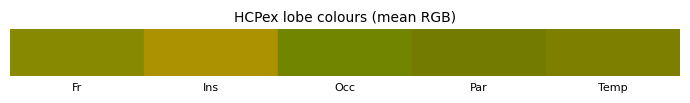

In [9]:
# RGB colours are stored per region — useful for consistent colouring in custom plots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Aggregate to one representative colour per lobe
lobe_palette = (
    hcpex.labels.dropna(subset=["lobe"])
    .groupby("lobe")[["r", "g", "b"]]
    .mean()
    .astype(int)
)

fig, ax = plt.subplots(figsize=(7, 1.2))
ax.set_xlim(0, len(lobe_palette))
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("HCPex lobe colours (mean RGB)", fontsize=10)

for i, (lobe, row) in enumerate(lobe_palette.iterrows()):
    colour = tuple(row[["r", "g", "b"]] / 255)
    ax.add_patch(mpatches.Rectangle((i, 0), 1, 1, color=colour))
    ax.text(i + 0.5, -0.15, lobe, ha="center", va="top", fontsize=8)

plt.tight_layout()
plt.show()

---

## 4. HCP-MMP 1.0 — Surface Atlas

360-region (180/hemisphere) cortical parcellation in **fsLR 32k surface space**. `get_atlas()` returns separate GIFTI paths for left and right hemispheres.

In [10]:
hcpmmp = snbb.get_atlas("HCPMMP")

print(f"modality : {hcpmmp.modality}")
print(f"space    : {hcpmmp.space}")
print(f"maps     : {hcpmmp.maps.name}")
print(f"maps_R   : {hcpmmp.maps_R.name}")
print(f"labels   : {len(hcpmmp.labels)} regions")

modality : surface
space    : fsLR
maps     : atlas-HCPMMP_space-fsLR_hemi-L_dseg.label.gii
maps_R   : atlas-HCPMMP_space-fsLR_hemi-R_dseg.label.gii
labels   : 360 regions


In [11]:
# Fetch a single hemisphere
lh_only = snbb.get_atlas("HCPMMP", hemi="L")
print(f"Left-only: maps={lh_only.maps.name}, maps_R={lh_only.maps_R}")

# Load the GIFTI with nibabel
gifti = nib.load(hcpmmp.maps)
vertex_labels = gifti.darrays[0].data
print(f"\nGIFTI vertex array shape: {vertex_labels.shape}  (one label per 32k vertex)")
print(f"Unique non-zero labels   : {len(np.unique(vertex_labels[vertex_labels > 0]))}")

Left-only: maps=atlas-HCPMMP_space-fsLR_hemi-L_dseg.label.gii, maps_R=None

GIFTI vertex array shape: (32492,)  (one label per 32k vertex)
Unique non-zero labels   : 180


In [12]:
hcpmmp.labels.head(8)

,index,label,name,hemisphere,region_abbrev,lobe,cortex_type,x_cog,y_cog,z_cog,volume_mm3
0,1,V1_L,Primary_Visual_Cortex_L,L,V1,Occ,Primary_Visual,100.491589,41.138901,71.637040,6717
1,2,MST_L,Medial_Superior_Temporal_Area_L,L,MST,Occ,MT+_Complex_and_Neighboring_Visual_Areas,132.416667,58.901786,82.059524,336
2,3,V6_L,Sixth_Visual_Area_L,L,V6,Occ,Dorsal_Stream_Visual,104.543112,44.481665,103.916749,1009
3,4,V2_L,Second_Visual_Area_L,L,V2,Occ,Early_Visual,102.236656,44.064791,74.401125,6220
4,5,V3_L,Third_Visual_Area_L,L,V3,Occ,Early_Visual,107.926111,40.632159,76.961153,4994
5,6,V4_L,Fourth_Visual_Area_L,L,V4,Occ,Early_Visual,120.481621,41.344329,69.955702,3183
6,7,V8_L,Eighth_Visual_Area_L,L,V8,Occ,Ventral_Stream_Visual,123.013193,51.892700,56.759015,1137
7,8,4_L,Primary_Motor_Cortex_L,L,4,Fr,Somatosensory_and_Motor,119.338359,105.485002,126.655610,6301


In [13]:
# Distribution across lobes and cortex types
print("Regions per lobe:")
print(hcpmmp.labels["lobe"].value_counts().to_string())

print("\nTop cortex types (top 8):")
print(hcpmmp.labels["cortex_type"].value_counts().head(8).to_string())

Regions per lobe:
lobe
Fr      132
Par      96
Temp     69
Occ      47
Ins      16

Top cortex types (top 8):
cortex_type
Anterior_Cingulate_and_Medial_Prefrontal    32
Posterior_Cingulate                         26
Dorsolateral_Prefrontal                     26
Insular_and_Frontal_Opercular               24
Superior_Parietal                           20
Inferior_Parietal                           20
MT+_Complex_and_Neighboring_Visual_Areas    18
Paracentral_Lobular_and_Mid_Cingulate       18


---

## 5. Schaefer2018 + Tian — Combined Atlases

40 combined atlases: every combination of **10 Schaefer cortical resolutions** (100–1000 regions, 7-network solution) with **4 Tian subcortical scales** (S1–S4). Labels include a `component` column (`"cortex"` / `"subcortex"`) and a `network` column for cortical regions.

In [14]:
schaefer = snbb.get_atlas("Schaefer2018N400n7Tian2020S2")
print(f"{schaefer.atlas_id}")
print(f"  {len(schaefer.labels)} total regions")
print(f"  columns: {list(schaefer.labels.columns)}")
print()
print(schaefer.labels["component"].value_counts().to_string())

Schaefer2018N400n7Tian2020S2
  432 total regions
  columns: ['index', 'label', 'name', 'hemisphere', 'network', 'component']

component
cortex       400
subcortex     32


In [15]:
# Cortical regions carry 7-network assignments
cortex_rows = schaefer.labels[schaefer.labels["component"] == "cortex"]
print("Cortical regions per network:")
print(cortex_rows["network"].value_counts().to_string())

print("\nSubcortical regions (TianS2):")
print(
    schaefer.labels[schaefer.labels["component"] == "subcortex"][["label", "hemisphere"]]
    .to_string(index=False)
)

Cortical regions per network:
network
Default        91
SomMot         77
Vis            61
Cont           52
SalVentAttn    47
DorsAttn       46
Limbic         26

Subcortical regions (TianS2):
       label hemisphere
     aHIP-rh          R
     pHIP-rh          R
     lAMY-rh          R
     mAMY-rh          R
   THA-DP-rh          R
   THA-VP-rh          R
   THA-VA-rh          R
   THA-DA-rh          R
NAc-shell-rh          R
 NAc-core-rh          R
      pGP-rh          R
      aGP-rh          R
     aPUT-rh          R
     pPUT-rh          R
     aCAU-rh          R
     pCAU-rh          R
     aHIP-lh          L
     pHIP-lh          L
     lAMY-lh          L
     mAMY-lh          L
   THA-DP-lh          L
   THA-VP-lh          L
   THA-VA-lh          L
   THA-DA-lh          L
NAc-shell-lh          L
 NAc-core-lh          L
      pGP-lh          L
      aGP-lh          L
     aPUT-lh          L
     pPUT-lh          L
     aCAU-lh          L
     pCAU-lh          L


In [16]:
# All 40 Schaefer-Tian variants — total region counts
records = []
for n in [100, 200, 400, 600, 1000]:
    for s in [1, 2, 3, 4]:
        atlas_id = f"Schaefer2018N{n}n7Tian2020S{s}"
        labels = snbb.get_atlas(atlas_id).labels
        records.append(
            {"N": n, "S": s, "cortex": (labels["component"] == "cortex").sum(),
             "subcortex": (labels["component"] == "subcortex").sum(),
             "total": len(labels)}
        )

summary = pd.DataFrame(records)
print(summary.pivot(index="N", columns="S", values="total").to_string())

S        1     2     3     4
N                           
100    116   132   150   154
200    216   232   250   254
400    416   432   450   454
600    616   632   650   654
1000  1016  1032  1050  1054


---

## 6. Loading Images with nibabel

The `maps` attribute is a `pathlib.Path` — you load the image yourself.

In [17]:
# Volumetric NIfTI
atlas = snbb.get_atlas("TianS1")
img = nib.load(atlas.maps)

print(f"Image shape  : {img.shape}")
print(f"Voxel size   : {img.header.get_zooms()} mm")
print(f"Affine (first row): {img.affine[0]}")

data = img.get_fdata()
unique_labels = np.unique(data[data > 0]).astype(int)
print(f"Non-zero labels: {unique_labels}")

Image shape  : (193, 229, 193)
Voxel size   : (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
Affine (first row): [  1.   0.   0. -96.]
Non-zero labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


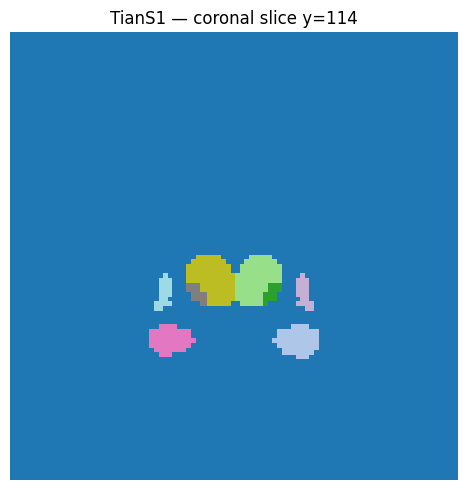

In [18]:
# Quick coronal slice through the subcortex
import matplotlib.pyplot as plt

data = img.get_fdata()
slice_y = data.shape[1] // 2   # coronal mid-slice

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(data[:, slice_y, :].T, origin="lower", cmap="tab20", interpolation="nearest")
ax.set_title(f"TianS1 — coronal slice y={slice_y}")
ax.axis("off")
plt.tight_layout()
plt.show()

In [19]:
# Compute voxel volume per region and compare to TSV x/y/z centres
voxel_vol_mm3 = np.prod(img.header.get_zooms())  # 1.0 mm³ at 1 mm isotropic
data_int = data.astype(int)
voxel_counts = {lbl: np.sum(data_int == lbl) for lbl in unique_labels}

region_vols = (
    atlas.labels
    .assign(volume_mm3=lambda df: df["index"].map(
        {lbl: cnt * voxel_vol_mm3 for lbl, cnt in voxel_counts.items()}
    ))
    [["label", "hemisphere", "structure", "volume_mm3"]]
)
print(region_vols.to_string(index=False))

  label hemisphere structure  volume_mm3
 HIP-rh          R       HIP      5399.0
 AMY-rh          R       AMY      2922.0
pTHA-rh          R      pTHA      3096.0
aTHA-rh          R      aTHA      6944.0
 NAc-rh          R       NAc      1932.0
  GP-rh          R        GP      1596.0
 PUT-rh          R       PUT      7659.0
 CAU-rh          R       CAU      3556.0
 HIP-lh          L       HIP      5358.0
 AMY-lh          L       AMY      2980.0
pTHA-lh          L      pTHA      3332.0
aTHA-lh          L      aTHA      7328.0
 NAc-lh          L       NAc      2035.0
  GP-lh          L        GP      1584.0
 PUT-lh          L       PUT      7551.0
 CAU-lh          L       CAU      3886.0


---

## 7. Error Handling

The API raises descriptive errors for invalid inputs.

In [20]:
# Unknown atlas ID
try:
    snbb.get_atlas("DoesNotExist")
except KeyError as e:
    print(f"KeyError: {e}")

# hemi= on a volumetric atlas
try:
    snbb.get_atlas("TianS1", hemi="L")
except ValueError as e:
    print(f"ValueError: {e}")

# Mesh not yet built
try:
    snbb.get_mesh("TianS1")  # raises FileNotFoundError if derivatives not populated
    print("Mesh found at:", snbb.get_mesh("TianS1"))
except FileNotFoundError as e:
    print(f"FileNotFoundError: {e}")

KeyError: "Unknown atlas 'DoesNotExist'. Call list_atlases() to see available atlases."
ValueError: Atlas 'TianS1' is volumetric; 'hemi' must be None, got 'L'.
Mesh found at: /media/storage/yalab-dev/snbb_atlas_pack/derivatives/yabplot/atlas-TianS1


---

## Summary

| Function | Returns | Notes |
|----------|---------|-------|
| `snbb.list_atlases()` | `list[str]` | Sorted list of all 46 atlas IDs |
| `snbb.get_atlas(id)` | `AtlasResult` | `maps` (Path) + `labels` (DataFrame) |
| `snbb.get_atlas(id, hemi="L")` | `AtlasResult` | Surface atlases only |
| `snbb.get_mesh(id)` | `Path` | Prebuilt yabplot mesh directory |
| `snbb.list_meshes()` | `dict` | `{atlas_id: [components]}` |
| `snbb.build_meshes(id)` | `None` | Build/rebuild yabplot mesh cache |

Continue to **`02_visualization.ipynb`** for atlas figure display and custom data overlays.